# Аналіз текстів

## Що таке аналіз текстів?

Обробка текстів (text mining), також відомий як текстова аналітика, - це процес пошуку значущої інформації та інсайтів з неструктурованих текстових даних. Дана область поєднує техніки з обробки природної мови (natural language processing, NLP), машинного навчання та інтелектуального аналізу даних для пошуку патернів, трендів та зв'язків у текстовому контенті.

### Ключові характеристики текстових даних
- **Неструктуровані**: Текст не має попередньо визначеного формату, як бази даних
- **Високовимірні**: Кожне унікальне слово може розглядатися як окремий вимір
- **Розріджені**: Більшість документів містить лише невелику підмножину всіх можливих слів
- **Шумні**: Містить друкарські помилки, абревіатури, сленг та неузгоджене форматування

### Застосування

1. **Інформаційний пошук**
   - Пошукові системи (Google, Bing)
   - Пошук документів та системи рекомендацій

2. **Аналіз тональності**
   - Моніторинг соціальних мереж
   - Аналіз відгуків клієнтів
   - Управління репутацією бренду

3. **Класифікація документів**
   - Виявлення спаму в електронній пошті
   - Категоризація новин
   - Сортування юридичних документів

4. **Рекомендація контенту**
   - Рекомендації фільмів Netflix
   - Пропозиції продуктів Amazon
   - Рекомендації новинних статей

5. **Бізнес-аналітика**
   - Дослідження ринку
   - Конкурентний аналіз
   - Автоматизація підтримки клієнтів

6. **Академічні дослідження**
   - Автоматизація огляду літератури
   - Кластеризація наукових статей
   - Аналіз цитувань

## Процес текстового аналізу

Типовий робочий процес текстового аналізу включає кілька ключових кроків:

1. **Збір даних**: Збір текстів з різних джерел
2. **Попередня обробка тексту**: Очищення та нормалізація текстів
3. **Кодування/інженерія ознак**: Перетворення текстів в числові представлення
4. **Пошук патернів**: Застосування алгоритмів data mining
5. **Оцінка**: Оцінка якості виявлених патернів
6. **Візуалізація**: Представлення результатів у зрозумілих форматах

## Попередня обробка текстів

Попередня обробка текстів - це критичний крок у текстовій аналітиці, який перетворює сирий текст у чистий, стандартизований формат, придатний для аналізу. Якість попередньої обробки безпосередньо впливає на якість подальших алгоритмів видобутку тексту.

### Чому важлива попередня обробка тексту?

Сирий текст часто містить:
- Неузгоджений регістр
- Пунктуацію та спеціальні символи
- Стоп-слова (загальні слова, такі як "the", "and", "is")
- Друкарські та орфографічні помилки
- HTML-теги, URL-адреси та адреси електронної пошти
- Числа та спеціальні символи

### Загальні техніки попередньої обробки

#### 1. Токенізація
Розбиття тексту на окремі слова або токени.

#### 2. Нормалізація
- **Приведення до нижнього регістру**: Перетворення всього тексту на нижній регістр
- **Стемінг**: Зведення слів до їх кореневої форми (наприклад, "running" → "run")
- **Лематизація**: Перетворення слів на їх словникову форму (наприклад, "better" → "good")

#### 3. Очищення
- Видалення HTML-тегів, URL-адрес та адрес електронної пошти
- Обробка спеціальних символів та чисел
- Видалення зайвих пробілів

#### 4. Видалення стоп-слів
Видалення загальних слів, які не несуть багато значення.

#### 5. Фільтрація
- Видалення слів, які з'являються занадто часто або занадто рідко

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

try:
    nltk.download('punkt')
    nltk.download('punkt_tab')
    nltk.download('stopwords')
    nltk.download('wordnet')
except:
    print("NLTK data already downloaded or download failed")

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

[nltk_data] Downloading package punkt to /Users/roman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/roman/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/roman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/roman/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
sample_texts = [
    "The quick brown fox jumps over the lazy dog. This is a sample sentence for text mining.",
    "Text mining is the process of extracting meaningful information from unstructured text data.",
    "Machine learning algorithms can be applied to text data for classification and clustering.",
    "Natural language processing combines computational linguistics with machine learning.",
    "Data science involves statistics, programming, and domain expertise to extract insights.",
    "The fox is quick and the dog is lazy. Text processing requires careful preprocessing steps.",
    "Machine learning models need training data to learn patterns and make predictions.",
    "Natural language understanding is a challenging problem in artificial intelligence."
]

print("Тестові документи:")
for i, text in enumerate(sample_texts, 1):
    print(f"Документ {i}: {text}")
    print()

Тестові документи:
Документ 1: The quick brown fox jumps over the lazy dog. This is a sample sentence for text mining.

Документ 2: Text mining is the process of extracting meaningful information from unstructured text data.

Документ 3: Machine learning algorithms can be applied to text data for classification and clustering.

Документ 4: Natural language processing combines computational linguistics with machine learning.

Документ 5: Data science involves statistics, programming, and domain expertise to extract insights.

Документ 6: The fox is quick and the dog is lazy. Text processing requires careful preprocessing steps.

Документ 7: Machine learning models need training data to learn patterns and make predictions.

Документ 8: Natural language understanding is a challenging problem in artificial intelligence.



In [3]:
def preprocess_text(text, remove_stopwords=True, stem=True, lemmatize=False):
    text = text.lower()
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [token for token in tokens if token not in stop_words]
    if lemmatize:
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
    elif stem:
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(token) for token in tokens]
    return ' '.join(tokens)

print("Оригінальний текст:")
print(sample_texts[0])

print("\nПопередньо оброблений текст (видалені стоп-слова + стемінг):")
print(preprocess_text(sample_texts[0]))

print("\nПопередньо оброблений текст (без видалення стоп-слів):")
print(preprocess_text(sample_texts[0], remove_stopwords=False))

print("\nПопередньо оброблений текст (з лемматизацією замість стемінгу):")
print(preprocess_text(sample_texts[0], stem=False, lemmatize=True))

Оригінальний текст:
The quick brown fox jumps over the lazy dog. This is a sample sentence for text mining.

Попередньо оброблений текст (видалені стоп-слова + стемінг):
quick brown fox jump lazi dog sampl sentenc text mine

Попередньо оброблений текст (без видалення стоп-слів):
the quick brown fox jump over the lazi dog thi is a sampl sentenc for text mine

Попередньо оброблений текст (з лемматизацією замість стемінгу):
quick brown fox jump lazy dog sample sentence text mining


In [4]:
preprocessed_texts = [preprocess_text(text) for text in sample_texts]

print("Попередньо оброблені документи:")
for i, text in enumerate(preprocessed_texts, 1):
    print(f"Документ {i}: {text}")
    print()

all_words = []
for text in preprocessed_texts:
    all_words.extend(text.split())

word_freq = Counter(all_words)
print(f"Унікальних слів загалом: {len(word_freq)}")
print(f"Найпоширеніші слова: {word_freq.most_common(10)}")

Попередньо оброблені документи:
Документ 1: quick brown fox jump lazi dog sampl sentenc text mine

Документ 2: text mine process extract meaning inform unstructur text data

Документ 3: machin learn algorithm appli text data classif cluster

Документ 4: natur languag process combin comput linguist machin learn

Документ 5: data scienc involv statist program domain expertis extract insight

Документ 6: fox quick dog lazi text process requir care preprocess step

Документ 7: machin learn model need train data learn pattern make predict

Документ 8: natur languag understand challeng problem artifici intellig

Унікальних слів загалом: 49
Найпоширеніші слова: [('text', 5), ('data', 4), ('learn', 4), ('process', 3), ('machin', 3), ('quick', 2), ('fox', 2), ('lazi', 2), ('dog', 2), ('mine', 2)]


## Модель "Мішок слів"

Модель **"Мішок слів" (Bag of Words, BoW)** - одна з найпростіших та найбільш широко використовуваних технік представлення тексту. Вона розглядає кожен документ як "мішок" слів, ігноруючи порядок та структуру слів, але відстежуючи їх частоту.

### Проблема, яку вирішує BoW

Перед тим, як ми застосувати алгоритми машинного навчання до текстових даних, потрібно перетворити неструктурований текст у числові представлення. Фундаментальний виклик полягає в тому, що:

1. **Текст неструктурований**: Сирий текст містить слова, пунктуацію та форматування, які алгоритми не можуть безпосередньо обробляти
2. **Змінна довжина**: Документи різні за довжиною
3. **Висока розмірність**: Кожне унікальне слово може бути ознакою, що призводить до дуже високовимірних просторів
4. **Розрідженість**: Більшість документів містить лише невелику підмножину всіх можливих слів

**BoW вирішує ці виклики:**
- Перетворюючи текст у вектори фіксованої довжини
- Використовуючи інформацію про частоту слів, яка часто вказує на вміст документа

### Коли використовувати "Мішок слів"

- Документи досить довгі (більше слів = краща статистика)
- Частота слів є значущою (наприклад, "машинне навчання" часто з'являється в статтях про ML)
- Потрібна проста, швидка, інтерпретована модель
- Обчислювальні ресурси обмежені

### Як працює "Мішок слів"

1. **Створення словника**: Зібрати всі унікальні слова з усіх документів
2. **Векторизація**: Перетворити кожен документ у числовий вектор
3. **Підрахунок частоти**: Підрахувати, скільки разів кожне слово з'являється в кожному документі

Для документа $d$ та словника $V$, представлення "мішок слів" є:

$$\text{BoW}(d) = [f_1, f_2, f_3, \ldots, f_{|V|}]$$

Де $f_i$ - частота слова $i$ в документі $d$.

### Приклад

Розглянемо два документи:
- Документ 1: "The cat sat on the mat"
- Документ 2: "The dog sat on the log"

**Крок 1: Створити словник**
Словник: {the, cat, sat, on, mat, dog, log}

**Крок 2: Підрахувати частоти слів**
- Документ 1: "the"=2, "cat"=1, "sat"=1, "on"=1, "mat"=1, "dog"=0, "log"=0
- Документ 2: "the"=2, "cat"=0, "sat"=1, "on"=1, "mat"=0, "dog"=1, "log"=1

**Крок 3: Створити вектори**
- Документ 1: [2, 1, 1, 1, 1, 0, 0]
- Документ 2: [2, 0, 1, 1, 0, 1, 1]

### Особливості реалізації

**Управління розміром словника:**
- **Занадто малий**: Може пропустити важливі слова
- **Занадто великий**: Збільшує обчислювальну вартість та розрідженість
- **Загальний підхід**: Видалити дуже рідкісні слова (з'являються в < 2 документах) та дуже загальні слова (стоп-слова)

**Обробка різних довжин документів:**
- **Сирий підрахунок**: Довші документи мають вищі значення
- **Нормалізація**: Розділити на довжину документа для справедливого порівняння
- **Двійкове кодування**: Просто вказати наявність/відсутність слів

**Пам'ять та продуктивність:**
- Використовувати розріджені матриці для великих словників
- Розглянути техніки зменшення розмірності
- Реалізувати ефективні алгоритми підрахунку

### Переваги та обмеження

**Переваги:**
- Простий для розуміння та реалізації
- Добре працює для багатьох завдань класифікації тексту
- Обчислювально ефективний
- Інтерпретовані результати (ви можете бачити, які слова важливі)
- Працює з будь-яким алгоритмом машинного навчання

**Обмеження:**
- Ігнорує порядок слів та контекст ("not good" vs "good not")
- Високовимірні розріджені вектори
- Не захоплює семантичні зв'язки між словами
- Чутливий до розміру словника
- Погана якість на коротких документах
- Немає розуміння синонімів або пов'язаних термінів

In [6]:
def create_bag_of_words(documents):
    all_words = []
    for doc in documents:
        all_words.extend(doc.split())
    
    vocabulary = sorted(list(set(all_words)))
    vocab_to_index = {word: idx for idx, word in enumerate(vocabulary)}
    
    document_vectors = []
    for doc in documents:
        words = doc.split()
        vector = [0] * len(vocabulary)
        for word in words:
            if word in vocab_to_index:
                vector[vocab_to_index[word]] += 1
        document_vectors.append(vector)
    
    return vocabulary, document_vectors

vocabulary, bow_vectors = create_bag_of_words(preprocessed_texts)

print(f"Розмір словника: {len(vocabulary)}")
print(f"Словник: {vocabulary[:20]}...")
print(f"Кількість документів: {len(bow_vectors)}")
print(f"Розмірність векторів: {len(bow_vectors[0])}")

print("\nМатриця Bag of Words (перші 5 документів, перші 10 ознак):")
bow_df = pd.DataFrame(bow_vectors, columns=vocabulary)
print(bow_df)

Розмір словника: 49
Словник: ['algorithm', 'appli', 'artifici', 'brown', 'care', 'challeng', 'classif', 'cluster', 'combin', 'comput', 'data', 'dog', 'domain', 'expertis', 'extract', 'fox', 'inform', 'insight', 'intellig', 'involv']...
Кількість документів: 8
Розмірність векторів: 49

Матриця Bag of Words (перші 5 документів, перші 10 ознак):
   algorithm  appli  artifici  brown  care  challeng  classif  cluster  \
0          0      0         0      1     0         0        0        0   
1          0      0         0      0     0         0        0        0   
2          1      1         0      0     0         0        1        1   
3          0      0         0      0     0         0        0        0   
4          0      0         0      0     0         0        0        0   
5          0      0         0      0     1         0        0        0   
6          0      0         0      0     0         0        0        0   
7          0      0         1      0     0         1        0  

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(bow_vectors)

print("=== Аналіз схожості документів ===")
print(f"Форма матриці схожості: {similarity_matrix.shape}")
print("\nКосинусна схожість між документами:")
print("(Значення ближчі до 1 означають більшу схожість документів)")

doc_labels = [f"Документ {i+1}" for i in range(len(sample_texts))]
similarity_df = pd.DataFrame(similarity_matrix, 
                            index=doc_labels, 
                            columns=doc_labels)

print("\nМатриця схожості:")
print(similarity_df.round(3))

print("\n=== Найбільш схожі пари документів ===")
upper_tri_indices = np.triu_indices_from(similarity_matrix, k=1)
similarities = similarity_matrix[upper_tri_indices]
pairs = list(zip(upper_tri_indices[0], upper_tri_indices[1], similarities))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

for i, (doc1_idx, doc2_idx, sim_score) in enumerate(pairs_sorted[:3]):
    print(f"{i+1}. Документи {doc1_idx+1} і {doc2_idx+1}: {sim_score:.3f}")
    print(f"   Документ {doc1_idx+1}: {sample_texts[doc1_idx][:60]}...")
    print(f"   Документ {doc2_idx+1}: {sample_texts[doc2_idx][:60]}...")
    print()

total_elements = len(bow_vectors) * len(vocabulary)
non_zero_elements = np.count_nonzero(bow_vectors)
sparsity = 1 - (non_zero_elements / total_elements)

print(f"\nРозрідженість матриці BoW: {sparsity:.2%}")
print(f"Ненульових елементів: {non_zero_elements} з {total_elements}")
print(f"Середня схожість між документами: {np.mean(similarities):.3f}")

=== Аналіз схожості документів ===
Форма матриці схожості: (8, 8)

Косинусна схожість між документами:
(Значення ближчі до 1 означають більшу схожість документів)

Матриця схожості:
            Документ 1  Документ 2  Документ 3  Документ 4  Документ 5  \
Документ 1       1.000       0.286       0.112       0.000       0.000   
Документ 2       0.286       1.000       0.320       0.107       0.201   
Документ 3       0.112       0.320       1.000       0.250       0.118   
Документ 4       0.000       0.107       0.250       1.000       0.000   
Документ 5       0.000       0.201       0.118       0.000       1.000   
Документ 6       0.500       0.286       0.112       0.112       0.000   
Документ 7       0.000       0.087       0.408       0.306       0.096   
Документ 8       0.000       0.000       0.000       0.267       0.000   

            Документ 6  Документ 7  Документ 8  
Документ 1       0.500       0.000       0.000  
Документ 2       0.286       0.087       0.000  
Доку

## TF-IDF (Частота терміна - Обернена частота документа, Term frequency - inverse document frequency)

**TF-IDF** - це покращення "мішка слів", яке вирішує проблему домінування частих слів.

### Розуміння TF-IDF

TF-IDF поєднує дві метрики:

1. **Частота терміна (TF)**: Наскільки часто термін з'являється в документі
2. **Обернена частота документа (IDF)**: Наскільки рідкісний або загальний термін серед усіх документів

### Математична формулювання

**Частота терміна (TF):**
$$\text{TF}(t,d) = \frac{\text{кількість терміна } t \text{ в документі } d}{\text{загальна кількість термінів у документі } d}$$

**Обернена частота документа (IDF):**
$$\text{IDF}(t,D) = \log\left(\frac{\text{загальна кількість документів}}{\text{кількість документів, що містять термін } t}\right)$$

**TF-IDF:**
$$\text{TF-IDF}(t,d,D) = \text{TF}(t,d) \times \text{IDF}(t,D)$$

### Чому працює TF-IDF

- **Високий TF-IDF**: Терміни, які часто з'являються в конкретному документі, але рідко в корпусі
- **Низький TF-IDF**: Терміни, які часто з'являються в багатьох документах (як стоп-слова)
- **Нульовий TF-IDF**: Терміни, які не з'являються в документі

### Переваги TF-IDF

1. **Зменшує шум**: Загальні слова отримують нижчі ваги
2. **Підкреслює важливі терміни**: Рідкісні, але релевантні терміни отримують вищі ваги
3. **Краща схожість документів**: Більш значущі міри схожості
4. **Широко використовується**: Стандарт у інформаційному пошуку та видобутку тексту

### Обмеження

1. **Все ще ігнорує порядок слів**: Як і "мішок слів"
2. **Залежний від словника**: Продуктивність залежить від якості словника
3. **Немає семантичного розуміння**: Не захоплює значення слів

In [8]:
print("=== Порівняння BoW та TF-IDF у scikit-learn ===")

bow_vectorizer = CountVectorizer()
bow_matrix_sklearn = bow_vectorizer.fit_transform(preprocessed_texts)

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix_sklearn = tfidf_vectorizer.fit_transform(preprocessed_texts)

print(f"Форма матриці BoW (scikit-learn): {bow_matrix_sklearn.shape}")
print(f"Форма матриці TF-IDF (scikit-learn): {tfidf_matrix_sklearn.shape}")

feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix_sklearn.toarray()

print("\nТоп-5 термінів за оцінкою TF-IDF для кожного документа:")
for i in range(len(sample_texts)):
    doc_scores = tfidf_scores[i]
    top_indices = np.argsort(doc_scores)[-5:][::-1]
    top_terms = [(feature_names[idx], doc_scores[idx]) for idx in top_indices if doc_scores[idx] > 0]
    print(f"Документ {i+1}: {top_terms}")

=== Порівняння BoW та TF-IDF у scikit-learn ===
Форма матриці BoW (scikit-learn): (8, 49)
Форма матриці TF-IDF (scikit-learn): (8, 49)

Топ-5 термінів за оцінкою TF-IDF для кожного документа:
Документ 1: [('sampl', np.float64(0.3554707243369083)), ('jump', np.float64(0.3554707243369083)), ('brown', np.float64(0.3554707243369083)), ('sentenc', np.float64(0.3554707243369083)), ('quick', np.float64(0.2979122096288147))]
Документ 2: [('text', np.float64(0.48145506587430986)), ('unstructur', np.float64(0.3796482155534453)), ('meaning', np.float64(0.3796482155534453)), ('inform', np.float64(0.3796482155534453)), ('mine', np.float64(0.3181748341952562))]
Документ 3: [('algorithm', np.float64(0.4134444783653823)), ('classif', np.float64(0.4134444783653823)), ('appli', np.float64(0.4134444783653823)), ('cluster', np.float64(0.4134444783653823)), ('machin', np.float64(0.29899998281345574))]
Документ 4: [('linguist', np.float64(0.4091435150089371)), ('combin', np.float64(0.4091435150089371)), ('c

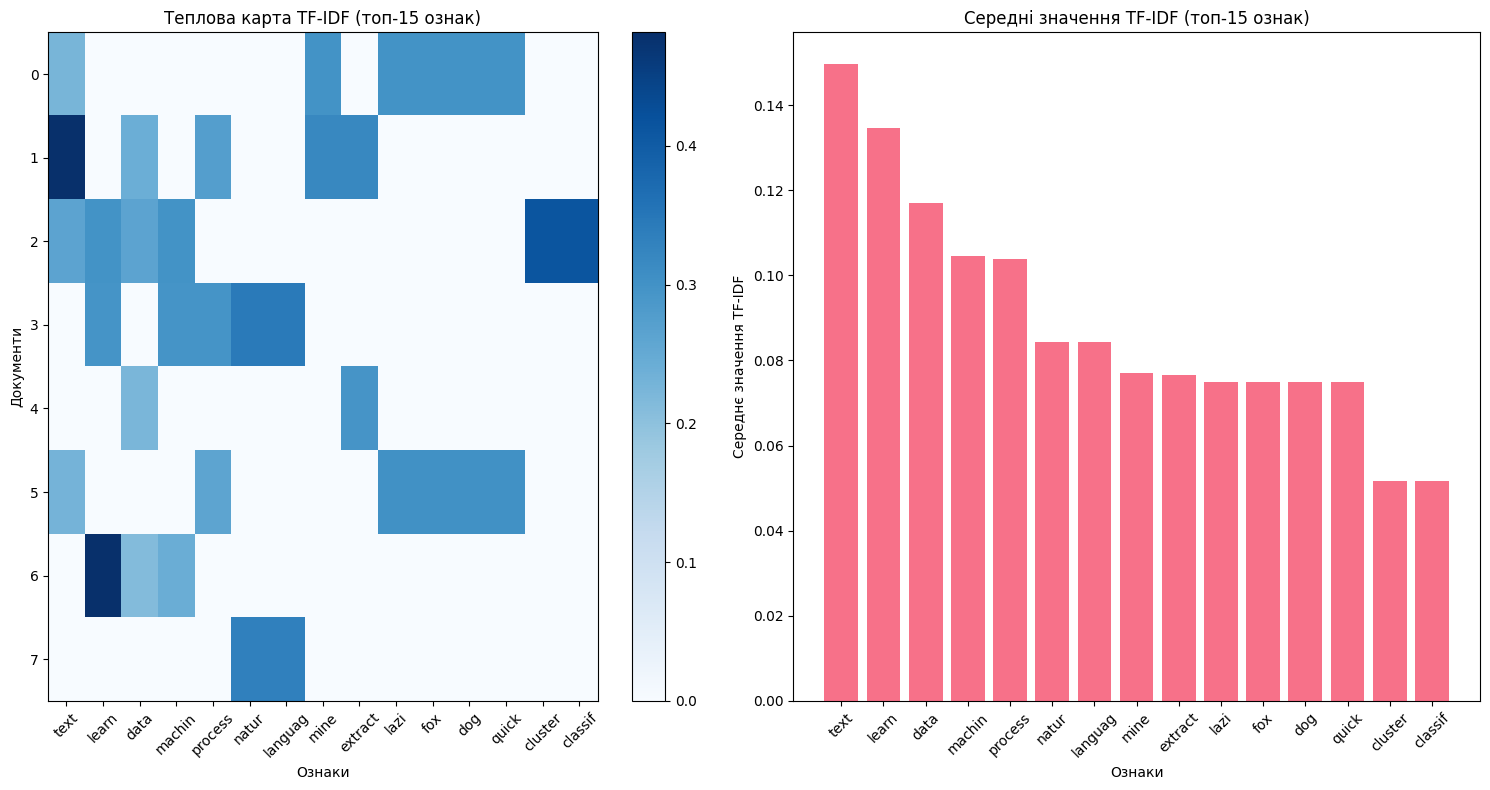

In [9]:
plt.figure(figsize=(15, 8))

tfidf_dense = tfidf_matrix_sklearn.toarray()
top_features = np.argsort(np.sum(tfidf_dense, axis=0))[-15:][::-1]

plt.subplot(1, 2, 1)
plt.imshow(tfidf_dense[:, top_features], cmap='Blues', aspect='auto')
plt.colorbar()
plt.title('Теплова карта TF-IDF (топ-15 ознак)')
plt.xlabel('Ознаки')
plt.ylabel('Документи')
plt.xticks(range(len(top_features)), [feature_names[i] for i in top_features], rotation=45)

plt.subplot(1, 2, 2)
avg_tfidf = np.mean(tfidf_dense, axis=0)
top_avg_indices = np.argsort(avg_tfidf)[-15:][::-1]
plt.bar(range(len(top_avg_indices)), avg_tfidf[top_avg_indices])
plt.xticks(range(len(top_avg_indices)), [feature_names[i] for i in top_avg_indices], rotation=45)
plt.title('Середні значення TF-IDF (топ-15 ознак)')
plt.xlabel('Ознаки')
plt.ylabel('Середнє значення TF-IDF')

plt.tight_layout()
plt.show()

## Кластеризація документів

Кластеризація документів - це процес групування подібних документів разом на основі їх вмісту. Це завдання навчання без вчителя, яке допомагає організувати великі колекції текстових документів та відкривати приховані патерни в даних.

### Навіщо кластеризувати документи?

1. **Організація**: Автоматично категоризувати документи без попередньо визначених міток
2. **Пошук**: Знаходити приховані теми в колекціях документів
3. **Ефективність**: Зменшити час, необхідний для знаходження релевантних документів
4. **Інсайти**: Розуміти структуру та вміст великих текстових корпусів

### Алгоритми кластеризації для тексту

#### 1. Кластеризація K-Means
- **Переваги**: Простий, швидкий, добре працює з високовимірними даними
- **Обмеження**: Потрібно визначити кількість кластерів, чутливий до ініціалізації
- **Найкраще працює**: Коли ви маєте уявлення про кількість кластерів

#### 2. Ієрархічна кластеризація
- **Переваги**: Немає потреби визначати кількість кластерів, створює дендрограми
- **Обмеження**: Обчислювально дорога для великих наборів даних
- **Найкраще працює**: Малі та середні набори даних, коли ви хочете дослідити ієрархію кластерів

#### 3. DBSCAN (на основі щільності)
- **Переваги**: Знаходить кластери довільних форм, обробляє шум
- **Обмеження**: Чутливий до параметрів, може мати проблеми з високовимірними даними
- **Найкраще працює**: Коли кластери мають різні щільності

### Міри відстані для тексту

Оскільки текстові дані зазвичай високовимірні та розріджені, нам потрібні відповідні міри відстані:

1. **Косинусна схожість**: Вимірює кут між векторами (найпоширеніша для тексту)
2. **Евклідова відстань**: Прямолінійна відстань між точками
3. **Манхеттенська відстань**: Сума абсолютних різниць

In [10]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def cluster_documents(tfidf_matrix, n_clusters=3, method='kmeans'):
    if method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    elif method == 'hierarchical':
        model = AgglomerativeClustering(n_clusters=n_clusters)
    else:
        raise ValueError("Метод має бути 'kmeans' або 'hierarchical'")
    
    cluster_labels = model.fit_predict(tfidf_matrix.toarray())
    return cluster_labels, model

n_clusters_range = range(2, 6)
silhouette_scores = []

print("Оцінювання різної кількості кластерів:")
for n_clusters in n_clusters_range:
    labels, _ = cluster_documents(tfidf_matrix_sklearn, n_clusters, 'kmeans')
    score = silhouette_score(tfidf_matrix_sklearn.toarray(), labels)
    silhouette_scores.append(score)
    print(f"Кількість кластерів = {n_clusters}: Silhouette Score = {score:.3f}")

best_n_clusters = n_clusters_range[np.argmax(silhouette_scores)]
print(f"\nНайкраща кількість кластерів: {best_n_clusters}")

final_labels, kmeans_model = cluster_documents(tfidf_matrix_sklearn, best_n_clusters, 'kmeans')

Оцінювання різної кількості кластерів:
Кількість кластерів = 2: Silhouette Score = 0.063
Кількість кластерів = 3: Silhouette Score = 0.074
Кількість кластерів = 4: Silhouette Score = 0.091
Кількість кластерів = 5: Silhouette Score = 0.072

Найкраща кількість кластерів: 4


In [11]:
print("=== Результати кластеризації документів ===")
print(f"Кількість кластерів: {best_n_clusters}")
print(f"Silhouette-коефіцієнт: {max(silhouette_scores):.3f}")

for cluster_id in range(best_n_clusters):
    cluster_docs = [i for i, label in enumerate(final_labels) if label == cluster_id]
    print(f"\nКластер {cluster_id} ({len(cluster_docs)} документів):")
    for doc_idx in cluster_docs:
        print(f"  Документ {doc_idx + 1}: {sample_texts[doc_idx][:80]}...")

print("\n=== Топ термів для кожного кластера ===")
for cluster_id in range(best_n_clusters):
    cluster_docs = [i for i, label in enumerate(final_labels) if label == cluster_id]
    if cluster_docs:
        cluster_tfidf = tfidf_matrix_sklearn[cluster_docs]
        avg_scores = np.mean(cluster_tfidf.toarray(), axis=0)
        top_indices = np.argsort(avg_scores)[-5:][::-1]
        top_terms = [(feature_names[idx], avg_scores[idx]) for idx in top_indices if avg_scores[idx] > 0]
        print(f"Кластер {cluster_id}: {top_terms}")

=== Результати кластеризації документів ===
Кількість кластерів: 4
Silhouette-коефіцієнт: 0.091

Кластер 0 (2 документів):
  Документ 3: Machine learning algorithms can be applied to text data for classification and c...
  Документ 7: Machine learning models need training data to learn patterns and make prediction...

Кластер 1 (2 документів):
  Документ 1: The quick brown fox jumps over the lazy dog. This is a sample sentence for text ...
  Документ 6: The fox is quick and the dog is lazy. Text processing requires careful preproces...

Кластер 2 (2 документів):
  Документ 2: Text mining is the process of extracting meaningful information from unstructure...
  Документ 5: Data science involves statistics, programming, and domain expertise to extract i...

Кластер 3 (2 документів):
  Документ 4: Natural language processing combines computational linguistics with machine lear...
  Документ 8: Natural language understanding is a challenging problem in artificial intelligen...

=== Топ тер

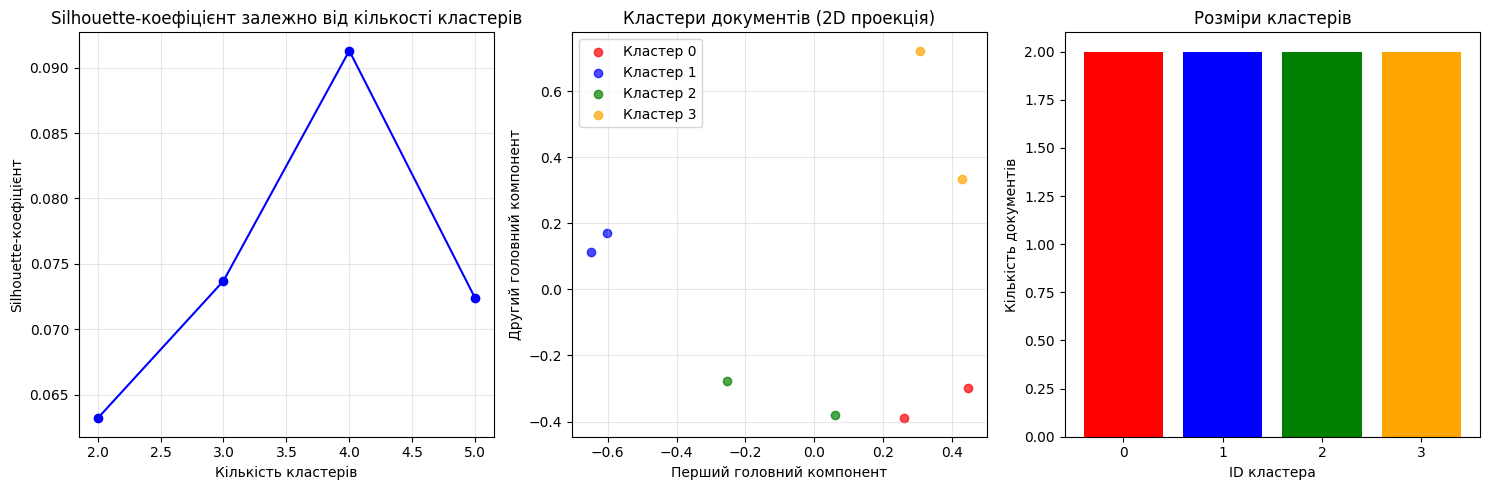

Пояснена дисперсія PCA: [0.21873058 0.17841407]
Загальна пояснена дисперсія: 0.397


In [12]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(n_clusters_range, silhouette_scores, 'bo-')
plt.xlabel('Кількість кластерів')
plt.ylabel('Silhouette-коефіцієнт')
plt.title('Silhouette-коефіцієнт залежно від кількості кластерів')
plt.grid(True, alpha=0.3)

pca = PCA(n_components=2)
tfidf_2d = pca.fit_transform(tfidf_matrix_sklearn.toarray())

plt.subplot(1, 3, 2)
colors = ['red', 'blue', 'green', 'orange', 'purple']
for cluster_id in range(best_n_clusters):
    cluster_mask = final_labels == cluster_id
    plt.scatter(tfidf_2d[cluster_mask, 0], tfidf_2d[cluster_mask, 1], 
               c=colors[cluster_id], label=f'Кластер {cluster_id}', alpha=0.7)
plt.xlabel('Перший головний компонент')
plt.ylabel('Другий головний компонент')
plt.title('Кластери документів (2D проекція)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
cluster_sizes = [np.sum(final_labels == i) for i in range(best_n_clusters)]
plt.bar(range(best_n_clusters), cluster_sizes, color=colors[:best_n_clusters])
plt.xlabel('ID кластера')
plt.ylabel('Кількість документів')
plt.title('Розміри кластерів')
plt.xticks(range(best_n_clusters))

plt.tight_layout()
plt.show()

print(f"Пояснена дисперсія PCA: {pca.explained_variance_ratio_}")
print(f"Загальна пояснена дисперсія: {sum(pca.explained_variance_ratio_):.3f}")